In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amisha0528/mall-customers-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.56k/1.56k [00:00<00:00, 3.49MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/amisha0528/mall-customers-dataset/versions/1


In [ ]:
import os
print(os.listdir(path))

['Mall_Customers.csv']


In [ ]:
df=pd.read_csv(path+'/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

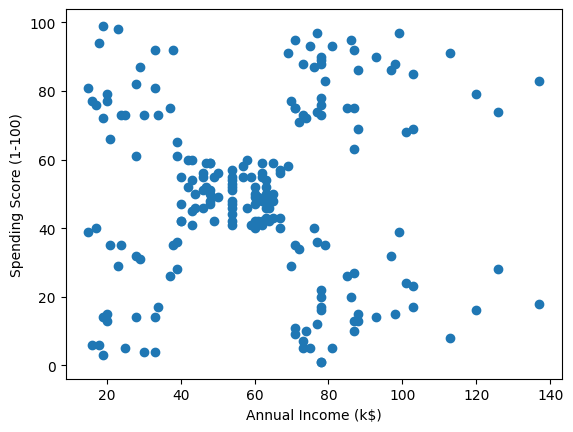

In [ ]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]

)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

##Elbow Method

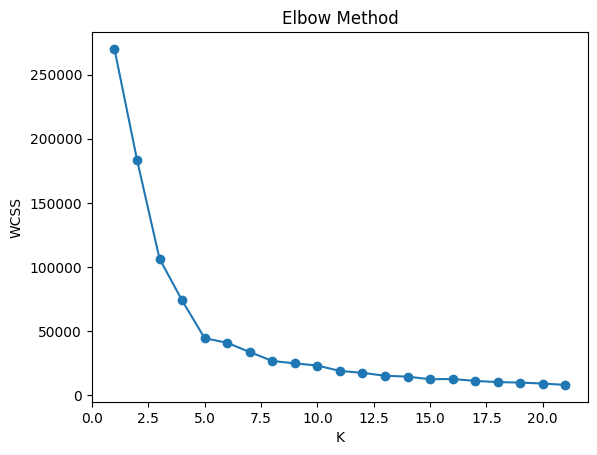

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,22):
  model=KMeans(n_clusters=k,random_state=42)
  model.fit(X)
  wcss.append(model.inertia_)
plt.plot(range(1,22),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Why "Repeat Until Centroids Stop Moving"?

When we run:

```python
clusters = model.fit_predict(X)
```

Scikit-Learn automatically performs these steps in the background:

```text
1. Place centroids
2. Assign points to nearest centroid
3. Calculate new centroids
4. Reassign points
5. Repeat
```

The process continues until the centroids no longer change (or change only by a tiny amount).

Then K-Means stops and returns:

```python
clusters
```

To see the final centroid positions:

```python
print(model.cluster_centers_)
```

### Simple Idea

```python
model.fit_predict(X)
```

is roughly equivalent to:

```python
while centroids_are_changing:
    assign_points_to_clusters()
    recalculate_centroids()
```

except Scikit-Learn does it automatically.

In [ ]:
model=KMeans(n_clusters=5,random_state=42)
clusters=model.fit_predict(X)
cluster0 = []
cluster1 = []
cluster2 = []
cluster3 = []
cluster4 = []

for i, k in enumerate(clusters):
    if k == 0:
        cluster0.append(i+1)
    elif k == 1:
        cluster1.append(i+1)
    elif k == 2:
        cluster2.append(i+1)
    elif k == 3:
        cluster3.append(i+1)
    elif k == 4:
        cluster4.append(i+1)

print("Cluster 0:", cluster0)
print("Cluster 1:", cluster1)
print("Cluster 2:", cluster2)
print("Cluster 3:", cluster3)
print("Cluster 4:", cluster4)

Cluster 0: [44, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 127, 133, 143]
Cluster 1: [124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198, 200]
Cluster 2: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 46]
Cluster 3: [125, 129, 131, 135, 137, 139, 141, 145, 147, 149, 151, 153, 155, 157, 159, 161, 163, 165, 167, 169, 171, 173, 175, 177, 179, 181, 183, 185, 187, 189, 191, 193, 195, 197, 199]
Cluster 4: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45]


In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
print(model.cluster_centers_)
#| Cluster | Income | Spending | Meaning                    |
#| ------- | ------ | -------- | -------------------------- |
#| 0       | 55     | 50       | Average customers          |
#| 1       | 87     | 82       | High income, high spending |
#| 2       | 26     | 79       | Low income, high spending  |
#| 3       | 88     | 17       | High income, low spending  |
#| 4       | 26     | 21       | Low income, low spending   |


[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Clusters,0


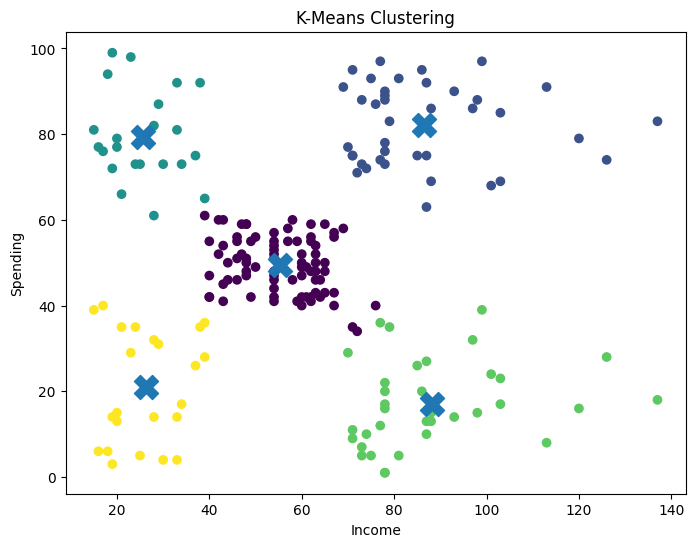

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=clusters
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("K-Means Clustering")

plt.show()

# K-Means Clustering Revision Notes

## 1. Why doesn't K-Means use a Y column?

Because K-Means is an **Unsupervised Learning Algorithm**.

There is no target/answer column.

### Supervised Learning

```python
X = Age, Income
Y = Churn
```

The model learns:

```text
Age + Income → Churn
```

### K-Means

```python
X = Income, Spending Score
```

There is no Y column.

The algorithm discovers groups automatically.

---

## 2. What is a Centroid?

A centroid is the **center point of a cluster**.

Example:

```text
(1,1)
(2,1)
(1,2)
```

Average:

```text
x = 1.33
y = 1.33
```

Centroid:

```text
(1.33, 1.33)
```

K-Means uses centroids to decide which cluster a point belongs to.

---

## 3. What does K = 5 mean?

```python
KMeans(n_clusters=5)
```

means:

> Create 5 clusters.

The algorithm will divide the data into 5 groups.

It does NOT mean there are definitely 5 natural groups.

---

## 4. Why do we use the Elbow Method?

The Elbow Method helps us find the best value of **K**.

Without it:

```text
K = 2 ?
K = 5 ?
K = 10 ?
```

We would just be guessing.

The Elbow Method helps choose a reasonable number of clusters.

---

## 5. What is WCSS?

**WCSS = Within-Cluster Sum of Squares**

It measures how close points are to their centroid.

```text
Point → Centroid
```

If points are close to the centroid:

```text
WCSS = Low
```

If points are far from the centroid:

```text
WCSS = High
```

K-Means tries to minimize WCSS.

---

## 6. What does `cluster_centers_` return?

It returns the coordinates of all centroids.

Example:

```python
print(kmeans.cluster_centers_)
```

Output:

```python
[
 [25,20],
 [90,85],
 [55,50],
 [90,15],
 [25,80]
]
```

Meaning:

```text
Cluster 0 centroid = (25,20)

Cluster 1 centroid = (90,85)

Cluster 2 centroid = (55,50)

Cluster 3 centroid = (90,15)

Cluster 4 centroid = (25,80)
```

For the Mall Customers Dataset:

```text
First value  = Annual Income
Second value = Spending Score
```

---

# K-Means Algorithm Flow

```text
Choose K
   ↓
Place Centroids Randomly
   ↓
Assign Points to Nearest Centroid
   ↓
Calculate New Centroids
   ↓
Reassign Points
   ↓
Repeat Until Centroids Stop Moving
```

---

# Quick Revision

## Cluster

A group of similar data points.

## Centroid

The center point of a cluster.

## K

Number of clusters to create.

## Elbow Method

Used to find the optimal value of K.

## WCSS

Measures how compact the clusters are.

## cluster_centers_

Returns the coordinates of all centroids.

## fit_predict()

Trains the model and returns cluster labels.

---

# Example

Dataset:

| Income | Spending Score |
|----------|----------|
| 20 | 15 |
| 25 | 20 |
| 90 | 85 |
| 95 | 80 |

K-Means Output:

```text
Cluster 0:
Low Income + Low Spending

Cluster 1:
High Income + High Spending
```

Business Interpretation:

```text
Cluster 0 → Budget Customers

Cluster 1 → Premium Customers
```